In [117]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob

In [133]:
sns.set_palette("crest")

In [119]:
temperatures = [-40,-30, -20,-10, 0, 25]

In [120]:
devices = ['LMG405', 'LMG450', 'LMG365', 'LMG520', 'KAPU465', 'KAPU405']

In [154]:
pocam =  8
hem1 = 23
hem2 = 24
batch=  'batch1'

In [155]:
n_photons_dict = {}

file_basepath_hem1 = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/{batch}/pocam_{pocam:03d}/hem_{hem1:.0f}/'
file_basepath_hem2 = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/{batch}/pocam_{pocam:03d}/hem_{hem2:.0f}/'

files = [file_basepath_hem1, file_basepath_hem2]
for file in files:
    for d in devices:
        n_photons = np.zeros((len(temperatures), 2))
        for i, t in enumerate(temperatures):
            if f'{hem1:.0f}' in file:
                hem = hem1
            if f'{hem2:.0f}' in file:
                hem = hem2
            if 'LMG' in d:
                suffix = '1-20'
            else:
                suffix = 'default'
        
            with open(file+f'{d}/photons_54000_{t:.0f}C_{suffix}.json', "r") as f:
                data = json.load(f)

            n_photons[i][0] = data['meas_data'][0]['value'] 
            n_photons[i][1] = data['meas_data'][0]['error']*data['meas_data'][0]['value']
                        
        n_photons_dict[f'{d}_{hem:.0f}'] = n_photons

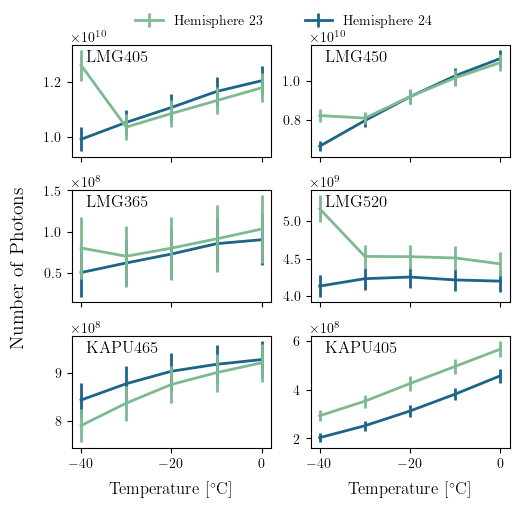

In [156]:
fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=.8, subplots=(3, 2)), sharex = True)

for i, ax in enumerate(axes.flat):
    d = devices[i]
    ax.errorbar(temperatures, n_photons_dict[f'{d}_{hem1:.0f}'][:,0], n_photons_dict[f'{d}_{hem1:.0f}'][:,1], 
                color = sns.color_palette()[0], zorder = 100,
                label=f'Hemisphere {hem1:.0f}')
    ax.errorbar(temperatures, n_photons_dict[f'{d}_{hem2:.0f}'][:,0], n_photons_dict[f'{d}_{hem2:.0f}'][:,1], 
                color = sns.color_palette()[4], alpha = 1,
                label=f'Hemisphere {hem2:.0f}')
    ax.text(0.07,0.85,f'{d}',transform = ax.transAxes)

    if i in [4, 5]:
        ax.set_xlabel(r'Temperature [$^\circ$C]')

axes[0][0].set_ylabel("Number of Photons", y=-1, size=14, labelpad=12)

# Single legend from the first subplot's handles, placed above the figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.96),
          columnspacing=3.0)

fig.subplots_adjust(hspace=0.3, wspace=0.2)
plt.savefig(f'plots/png/number_of_photons_pocam{pocam}.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/number_of_photons_pocam{pocam}.pdf', bbox_inches='tight')

In [136]:
temperatures = [-40,-30, -20,-10, 0]

<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fk/wtd7q1cd3dj875v4s60j7xvm0000gn/T/ipykernel_83923/2602191555.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax.hist(np.array(n_photons_distr)/10**10, bins = bins, histtype = 'step', lw = 2,label = f'T = ${T:.0f}^\circ$C')


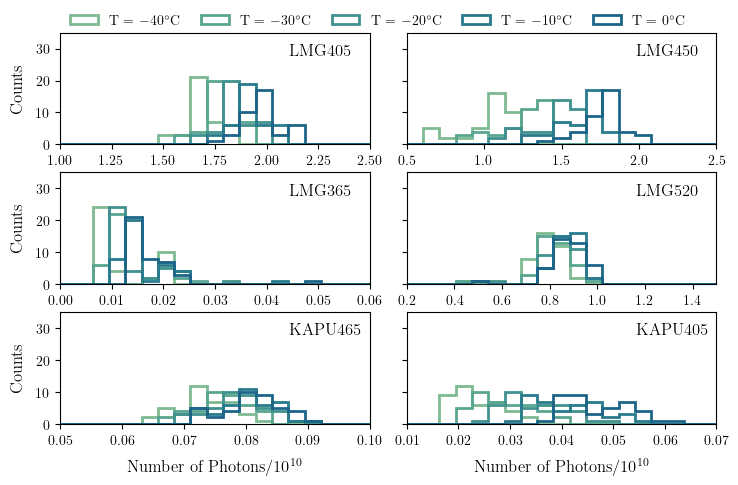

In [141]:
#now let's select all the number of emitter photons for a device and for a temperature and see the distribution
fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1.2, ratio= 0.4, subplots=(3, 2)), sharey=True)
for i, ax in enumerate(axes.flat):
    device = devices[i]
    if device == 'LMG450':
        bins = np.linspace(.5,2.5, 20 )
        ax.set_xlim(0.5,2.5)
    if device == 'LMG405':
        bins = np.linspace(1,2.5, 20 )
        ax.set_xlim(1,2.5)
    if device == 'LMG520':
        bins = np.linspace(0.2,1.5, 20 )
        ax.set_xlim(0.2,1.5)
    if device == 'LMG365':
        bins = np.linspace(0.,0.06,20)
        ax.set_xlim(0,0.06)
    if device == 'KAPU465':
        bins = np.linspace(0.05,0.1,20)
        ax.set_xlim(0.05,.1)
    if device == 'KAPU405':
        bins = np.linspace(0.01,0.07,20)
        ax.set_xlim(0.01,0.07)
        
    for T in temperatures:
        if 'LMG' in device:
            path = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif "KAPU" in device:
            path = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)

        n_photons_distr = []
        for file in filelist:
            with open(file, "r") as f:
                data = json.load(f)
            n_photons_distr.append(data['meas_data'][0]['value'])
    
        ax.hist(np.array(n_photons_distr)/10**10, bins = bins, histtype = 'step', lw = 2,label = f'T = ${T:.0f}^\circ$C')

        ax.set_ylim(0, 35)
        
    if i in [4,5]:
        ax.set_xlabel(r'Number of Photons$/10^{10}$')
    if i in [0,2,4]:
        ax.set_ylabel('Counts')
        
    
    ax.text(0.74,0.8, f'{device}', transform = ax.transAxes)
    
handles, labels = axes.flat[0].get_legend_handles_labels()    
fig.legend(handles, labels, loc='upper center', ncol=len(temperatures), bbox_to_anchor=(0.5, 0.94),
          columnspacing=1.5)
fig.subplots_adjust(hspace=0.25, wspace=.12)

plt.savefig(f'plots/png/number_of_photons_distr_all_Temperatures.png')
    

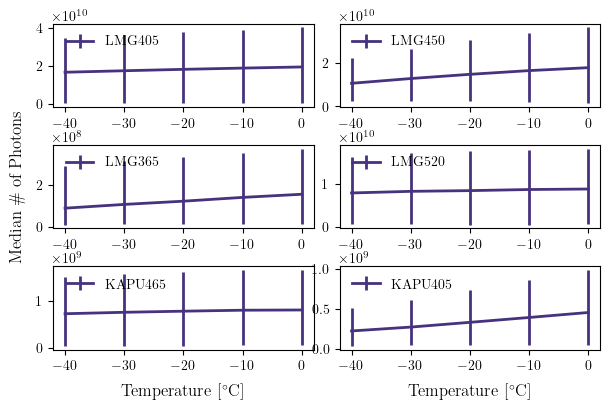

In [92]:
#now let's select all the number of emitter photons for a device and for a temperature and see the distribution
fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    n_photons_quantiles = {
        50: [],
        16: [],
        84: [],
    }
    for T in temperatures:
        photons_temp = []
        if "LMG" in device:
            path = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif "KAPU" in device:
            path = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)
        
        for file in filelist:
            with open(file, "r") as f:
                data = json.load(f)
            photons_temp.append(data['meas_data'][0]['value'])
            
        n_photons_quantiles[50].append(np.quantile(photons_temp, .5))
        n_photons_quantiles[16].append(np.quantile(photons_temp, .16))
        n_photons_quantiles[84].append(np.quantile(photons_temp, .84))
            
    ax.errorbar(temperatures,n_photons_quantiles[50],
               yerr=[n_photons_quantiles[16], n_photons_quantiles[84]],
               label = f"{device}")
    if i in [4,5]:
        ax.set_xlabel(r'Temperature [$^\circ$C]')
    if i ==2:
        ax.set_ylabel(r'Median \# of Photons')

    ax.legend(frameon = False,loc = 'upper left', ncol = 1)

fig.subplots_adjust(hspace=0.45, wspace=.1)
# fig.suptitle(f"Distribution of Number of Photons -- T = {T}\,C", y = 0.95)
plt.savefig(f'plots/png/median_numebr_of_photons_vs_T.png')

In [93]:
#check differences with coease/fine settings

In [109]:
coarse_fine = ['1-10', '1-20', '1-40','2-20',]

In [110]:
T = 0

In [111]:
number_of_photons_c_f = {}
FWHM_avg = {}
for c_f in coarse_fine:
    nf = []
    FWHM = []
    filepath = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/LMG405/photons_54000_{T}C_{c_f}.json'
    files = glob.glob(filepath)
    for file in files:
        with open(file, 'r') as f:
            data = json.load(f)
        nf.append(data['meas_data'][0]['value'])

    filepath_tdc = f'/Users/elenamanao/Documents/Pocam/FAT_data/output/batch2/pocam_*/hem_*/LMG405/tdc_54000_{T}C_{c_f}.json'
    files = glob.glob(filepath_tdc)
    for file in files:
        with open(file, 'r') as f:
            data = json.load(f)
        FWHM.append( data['meas_data'][1]['value'])
    

    number_of_photons_c_f[c_f] = nf
    FWHM_avg[c_f] = np.mean(FWHM)

In [112]:
FWHM_avg

{'1-10': 4.1057500000000005,
 '1-20': 5.84225,
 '1-40': 8.019499999999999,
 '2-20': 9.6055}

In [113]:
coarse_fine

['1-10', '1-20', '1-40', '2-20']

<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
/var/folders/fk/wtd7q1cd3dj875v4s60j7xvm0000gn/T/ipykernel_83923/1660105034.py:10: SyntaxWarning: invalid escape sequence '\,'
  fig.suptitle(f'T = {T}\,C')


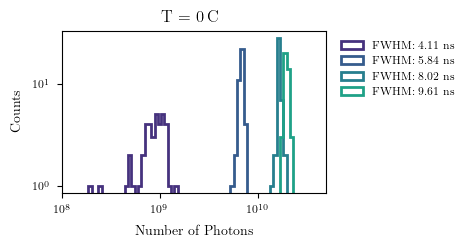

In [114]:
fig, ax = plt.subplots(1,1,figsize=plot_utils.set_size('colums', fraction=1, subplots=(1, 1)))

for c_f in coarse_fine:
    bins = np.logspace(8,10.5, 75)
    ax.hist(np.array(number_of_photons_c_f[c_f]),bins = bins, histtype = 'step', lw = 2,label = f'FWHM: {FWHM_avg[c_f]:.2f} ns')
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(ncol = 1, bbox_to_anchor = (1.02,1))
fig.suptitle(f'T = {T}\,C')
ax.set_xlabel('Number of Photons')
ax.set_ylabel('Counts')
ax.set_xlim(0.01*10**10, 5*10**10)
plt.savefig(f'plots/png/number_of_photons_coarse-fine_T{T}C.png')